In [435]:
from typing import List, TypedDict, Literal
from pydantic import BaseModel, Field
import time

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()
import os

In [436]:
docs = (
    PyPDFLoader("G:/Telegram Desktop/langGraph/self_rag/Company_Policies.pdf").load()
    + PyPDFLoader("G:/Telegram Desktop/langGraph/self_rag/Company_Profile.pdf").load()
    + PyPDFLoader("G:/Telegram Desktop/langGraph/self_rag/Product_and_Pricing.pdf").load()
)

In [437]:

chunks = RecursiveCharacterTextSplitter(
    chunk_size=600, chunk_overlap=150
).split_documents(docs)

In [438]:
api_key = os.getenv("GROQ_API_KEY")

llm = ChatOpenAI(
    model="openai/gpt-oss-120b",
    base_url="https://api.groq.com/openai/v1",
    api_key=api_key
)

In [439]:
from langchain_community.embeddings import HuggingFaceEmbeddings
# This downloads a tiny ~90MB transformer model that runs for free on your CPU
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 789.30it/s]


In [440]:
vector_store = FAISS.from_documents(chunks, embeddings)
retriever = vector_store.as_retriever(search_kwargs={"k": 4})

In [441]:
class State(TypedDict):

    query : str

    decision : bool

    retrieve_documents : List[Document]

    relevant_documents : List[Document]

    context : str

    answer : str

    issup: Literal["fully_supported", "partially_supported", "no_support"]
    evidence: List[str]

    retries: int

    isuse: Literal["useful", "not_useful"]
    use_reason: str

    retrieval_query: str
    rewrite_tries: int
    

In [442]:
class retriever_decision(BaseModel):

    should_retrieve : bool

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON that matches this schema:\n"
            "{{'should_retrieve': boolean}}\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve=False for general explanations, definitions, or reasoning that doesn't need sources.\n"
            "- If unsure, choose True."
        ),
        ("human", "Question: {query}"),
    ]
)

decision_taking_llm = llm.with_structured_output(retriever_decision)


In [443]:
def decide_retrieval(state:State):
    decision_made_by_llm : retriever_decision =decision_taking_llm.invoke(decide_retrieval_prompt.format_messages(query = state['query']))

    return {'decision' : decision_made_by_llm.should_retrieve}

    

In [444]:
def retrieve(state: State):
    q = state.get("retrieval_query") or state["query"]
    return {"retrieve_documents": retriever.invoke(q)}

In [445]:
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your general knowledge.\n"
            "Do NOT assume access to external documents.\n"
            "If you are unsure or the answer requires specific sources, say:\n"
            "'I don't know based on my general knowledge.'"
        ),
        ("human", "{query}"),
    ]
)


def generate_direct(state: State):
    out = llm.invoke(
        direct_generation_prompt.format_messages(
            query=state["query"]
        )
    )
    return {
        "answer": out.content
    }

In [446]:
def route_after_decide(state: State) -> Literal["generate_direct", "retrieve"]:
    if state["decision"]:
        return "retrieve"
    return "generate_direct"

In [447]:
class relevant_document_output_structure(BaseModel):

    is_relevant: bool = Field(
        ...,
        description="True if the document helps answer the question, else False."


    )

is_relevant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging document relevance.\n"
            "Return JSON that matches this schema:\n"
            "{{'is_relevant': boolean}}\n\n"
            "A document is relevant if it contains information useful for answering the question."
        ),
        (
            "human",
            "Question:\n{question}\n\nDocument:\n{document}"
        ),
    ]
)

relevance_llm = llm.with_structured_output(relevant_document_output_structure)



In [448]:
def is_relevant(state: State):
    
    relevant_docs: List[Document] = []

    for doc in state["retrieve_documents"]:
        decision: relevant_document_output_structure = relevance_llm.invoke(
            is_relevant_prompt.format_messages(
                question=state["query"],
                document=doc.page_content
            )
        )

        if decision.is_relevant:
            relevant_docs.append(doc)

    return {"relevant_documents": relevant_docs}

In [449]:
rag_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a business RAG assistant.\n"
            "Answer the user's question using ONLY the provided context.\n"
            "If the context does not contain enough information, say:\n"
            "'No relevant document found.'\n"
            "Do not use outside knowledge.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Context:\n{context}\n"
        ),
    ]
)


In [450]:
def generate_from_context(state : State):

    context = '\n\n----\n\n'.join(
        [
            d.page_content for d in state.get('relevant_documents',[])
        ]
    ).strip()

    if not context:
        return {'answer' : "No relevant document found.", "context": ""}

    out = llm.invoke(
        rag_generation_prompt.format_messages(
            question = state['query'],
            context = context
        )
    )

    return {"answer": out.content, "context": context}

In [451]:
def no_relevant_docs(state: State):
    return {"answer": "No relevant document found.", "context": ""}

In [452]:
def route_after_relevance(state: State) -> Literal["generate_from_context", "no_relevant_docs"]:
    if state.get("relevant_documents") and len(state["relevant_documents"]) > 0:
        return "generate_from_context"
    return "no_relevant_docs"

In [453]:
class IsSUPDecision(BaseModel):
    issup: Literal["fully_supported", "partially_supported", "no_support"]
    evidence: List[str] = Field(default_factory=list)

In [454]:
issup_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are verifying whether the ANSWER is supported by the CONTEXT.\n"
            "Return JSON with keys: issup, evidence.\n"
            "issup must be one of: fully_supported, partially_supported, no_support.\n\n"
            "How to decide issup:\n"
            "- fully_supported:\n"
            "  Every meaningful claim is explicitly supported by CONTEXT, and the ANSWER does NOT introduce\n"
            "  any qualitative/interpretive words that are not present in CONTEXT.\n"
            "  (Examples of disallowed words unless present in CONTEXT: culture, generous, robust, designed to,\n"
            "  supports professional development, best-in-class, employee-first, etc.)\n\n"
            "- partially_supported:\n"
            "  The core facts are supported, BUT the ANSWER includes ANY abstraction, interpretation, or qualitative\n"
            "  phrasing not explicitly stated in CONTEXT (e.g., calling policies 'culture', saying leave is 'generous',\n"
            "  or inferring outcomes like 'supports professional development').\n\n"
            "- no_support:\n"
            "  The key claims are not supported by CONTEXT.\n\n"
            "Rules:\n"
            "- Be strict: if you see ANY unsupported qualitative/interpretive phrasing, choose partially_supported.\n"
            "- If the answer is mostly unrelated to the question or unsupported, choose no_support.\n"
            "- Evidence: include up to 3 short direct quotes from CONTEXT that support the supported parts.\n"
            "- Do not use outside knowledge."
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Answer:\n{answer}\n\n"
            "Context:\n{context}\n"
        ),
    ]
)

In [455]:
issup_llm = llm.with_structured_output(IsSUPDecision)

def is_sup(state: State):
    decision: IsSUPDecision = issup_llm.invoke(
        issup_prompt.format_messages(
            question=state["query"],
            answer=state.get("answer", ""),
            context=state.get("context", ""),
        )
    )
    return {"issup": decision.issup, "evidence": decision.evidence}

In [456]:
revise_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a STRICT reviser.\n\n"
            "You must output based on the following format:\n\n"
            "FORMAT (quote-only answer):\n"
            "- <direct quote from the CONTEXT>\n"
            "- <direct quote from the CONTEXT>\n\n"
            "Rules:\n"
            "- Use ONLY the CONTEXT.\n"
            "- Do NOT add any new words besides bullet dashes and the quotes themselves.\n"
            "- Do NOT explain anything.\n"
            "- Do NOT say 'context', 'not mentioned', 'does not mention', 'not provided', etc.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Current Answer:\n{answer}\n\n"
            "CONTEXT:\n{context}"
        ),
    ]
)

In [457]:
def revise_answer(state: State):
    out = llm.invoke(
        revise_prompt.format_messages(
            question=state["query"],
            answer=state.get("answer", ""),
            context=state.get("context", ""),
        )
    )
    return {
        "answer": out.content,
        "retries": state.get("retries", 0) + 1,  # ✅ increment
    }

In [458]:
def accept_answer(state: State):
    return {}  # keep answer as-is

In [459]:
MAX_RETRIES = 10

def route_after_issup(state: State) -> Literal["accept_answer", "revise_answer"]:
    # accept if fully supported
    if state.get("issup") == "fully_supported":
        return "accept_answer"

    # stop if we've already tried enough
    if state.get("retries", 0) >= MAX_RETRIES:
        return "accept_answer"   # or return a "give_up" node if you want

    # otherwise revise again
    return "revise_answer"

In [460]:
class IsUSEDecision(BaseModel):
    isuse: Literal["useful", "not_useful"]
    reason: str = Field(..., description="Short reason in 1 line.")

isuse_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging USEFULNESS of the ANSWER for the QUESTION.\n\n"
            "Goal:\n"
            "- Decide if the answer actually addresses what the user asked.\n\n"
            "Return JSON with keys: isuse, reason.\n"
            "isuse must be one of: useful, not_useful.\n\n"
            "Rules:\n"
            "- useful: The answer directly answers the question or provides the requested specific info.\n"
            "- not_useful: The answer is generic, off-topic, or only gives related background without answering.\n"
            "- Do NOT use outside knowledge.\n"
            "- Do NOT re-check grounding (IsSUP already did that). Only check: 'Did we answer the question?'\n"
            "- Keep reason to 1 short line."
        ),
        (
            "human",
            "Question:\n{question}\n\nAnswer:\n{answer}"
        ),
    ]
)

isuse_llm = llm.with_structured_output(IsUSEDecision)

def is_use(state: State):
    decision: IsUSEDecision = isuse_llm.invoke(
        isuse_prompt.format_messages(
            question=state["query"],
            answer=state.get("answer", ""),
        )
    )
    return {"isuse": decision.isuse, "use_reason": decision.reason}


MAX_REWRITE_TRIES = 3  # tune (2–4 is usually fine)

def route_after_isuse(state: State) -> Literal["END", "rewrite_question", "no_answer_found"]:
    if state.get("isuse") == "useful":
        return "END"

    if state.get("rewrite_tries", 0) >= MAX_REWRITE_TRIES:
        return "no_answer_found"

    return "rewrite_question"

In [461]:
class RewriteDecision(BaseModel):
    retrieval_query: str = Field(
        ...,
        description="Rewritten query optimized for vector retrieval against internal company PDFs."
    )

rewrite_for_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Rewrite the user's QUESTION into a query optimized for vector retrieval over INTERNAL company PDFs.\n\n"
            "Rules:\n"
            "- Keep it short (6–16 words).\n"
            "- Preserve key entities (e.g., NexaAI, plan names).\n"
            "- Add 2–5 high-signal keywords that likely appear in policy/pricing docs.\n"
            "- Remove filler words.\n"
            "- Do NOT answer the question.\n"
            "- Output JSON with key: retrieval_query\n\n"
            "Examples:\n"
            "Q: 'Do NexaAI plans include a free trial?'\n"
            "-> {{'retrieval_query': 'NexaAI free trial duration trial period plans'}}\n\n"
            "Q: 'What is NexaAI refund policy?'\n"
            "-> {{'retrieval_query': 'NexaAI refund policy cancellation refund timeline charges'}}"
        ),
        (
            "human",
            "QUESTION:\n{question}\n\n"
            "Previous retrieval query:\n{retrieval_query}\n\n"
            "Answer (if any):\n{answer}"
        ),
    ]
)


In [462]:
rewrite_llm = llm.with_structured_output(RewriteDecision)

def rewrite_question(state: State):
    decision: RewriteDecision = rewrite_llm.invoke(
        rewrite_for_retrieval_prompt.format_messages(
            question=state["query"],
            retrieval_query=state.get("retrieval_query", ""),
            answer=state.get("answer", ""),
        )
    )

    return {
        "retrieval_query": decision.retrieval_query,
        "rewrite_tries": state.get("rewrite_tries", 0) + 1,
        "retrieve_documents": [],
        "relevant_documents": [],
        "context": "",
    }

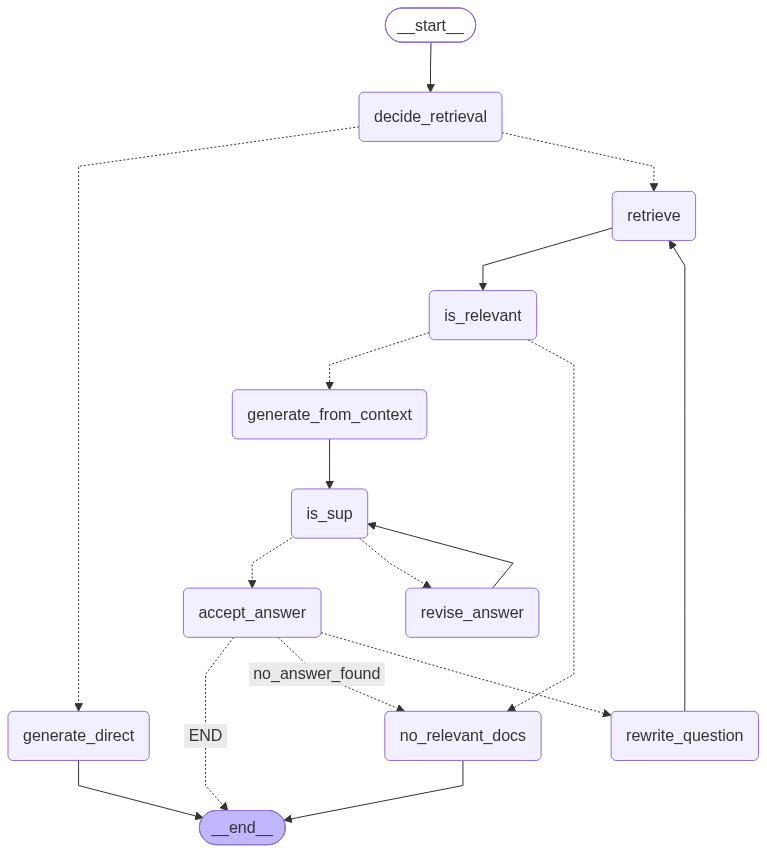

In [463]:
g = StateGraph(State)

# --------------------
# Nodes
# --------------------
g.add_node("decide_retrieval", decide_retrieval)
g.add_node("generate_direct", generate_direct)
g.add_node("retrieve", retrieve)
g.add_node("is_relevant", is_relevant)
g.add_node("generate_from_context",generate_from_context)
g.add_node("no_relevant_docs",no_relevant_docs)
g.add_node("is_sup", is_sup)

g.add_node("accept_answer", accept_answer)
g.add_node("revise_answer", revise_answer)

g.add_node("rewrite_question", rewrite_question)


# --------------------
# Edges
# --------------------
g.add_edge(START, "decide_retrieval")

g.add_conditional_edges(
    "decide_retrieval",
    route_after_decide,
    {
        "generate_direct": "generate_direct",
        "retrieve": "retrieve",
    },
)

g.add_edge("generate_direct", END)
g.add_edge("retrieve", "is_relevant")
g.add_conditional_edges(
    "is_relevant",
    route_after_relevance,
    {
        "generate_from_context": "generate_from_context",
        "no_relevant_docs": "no_relevant_docs",
    },
)

g.add_edge("generate_from_context", "is_sup")
g.add_conditional_edges(
    "is_sup",
    route_after_issup,  # fully_supported -> accept_answer else revise_answer
    {"accept_answer": "accept_answer", "revise_answer": "revise_answer"},
)

g.add_edge("revise_answer", "is_sup")  # 🔁 loop back to verify
g.add_edge("accept_answer", END)
g.add_conditional_edges(
    "accept_answer",
    route_after_isuse,
    {
        "END": END,
        "rewrite_question": "rewrite_question",
        "no_answer_found": "no_relevant_docs",
    },
)
g.add_edge("no_relevant_docs", END) 
# rewrite -> retrieve -> relevance -> ...
g.add_edge("rewrite_question", "retrieve") # temporary END for retrieval path

app = g.compile()
app

In [464]:
result = app.invoke(
    {
        "query": "Describe NexaAI’s company culture.?",
        "decision": False,
        "retrieve_documents": [],
        "answer": "",
        "evidence" : []
    }
)

print(result["answer"])
print(result["evidence"])
print("issup:", result.get("issup"))

# class State(TypedDict):

#     query : str

#     decision : bool

#     retrieve_docements : List[str]

#     answer = str

No relevant document found.
['NexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace.', 'Employees are encouraged to maintain a healthy work-life balance.']
issup: fully_supported


In [465]:
print(result["retrieve_documents"])

[Document(id='b748f5db-3591-42da-9035-dc69df2c21b9', metadata={'producer': 'ReportLab PDF Library - www.reportlab.com', 'creator': '(unspecified)', 'creationdate': '2026-02-14T13:07:17+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-02-14T13:07:17+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': 'G:/Telegram Desktop/langGraph/self_rag/Company_Policies.pdf', 'total_pages': 2, 'page': 0, 'page_label': '1'}, page_content='NexaAI Solutions – Company Policies\nHR Policies\nNexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace.\nAll employment decisions are made without discrimination.\n\x7f\nEqual opportunity employer\n\x7f\nBi-annual performance reviews\n\x7f\nClear career progression framework\n\x7f\nStrict anti-harassment policy\nLeave Policy\nEmployees are encouraged to maintain a healthy work-life balance.\n\x7f\nAnnual Leave: 18 working days per year\n\x7f\nSick Leave: 10 working days per year

In [466]:
result = app.invoke(
    {
        "query": "Do NexaAI plans include a free trial? If yes, how many days?",
        "decision": False,
        "retrieve_documents": [],
        "answer": "",
        "evidence" : []
    }
)

print(result["answer"])

No relevant document found.
